In [12]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [16]:
iris = datasets.load_iris()
#data # this is like a dict so far, not a dataframe...

X = iris.data
y =  iris.target

print(type(X))
print(type(y))

print(X.shape)
print(y.shape)

<class 'numpy.ndarray'>
,<class 'numpy.ndarray'>
,(150, 4)
,(150,)


In [17]:
# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


***************--Build a Decision Tree--*************************

***************--Sklearn Implementation--*************************

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score,recall_score
# Create a decision tree classifier model object.

decision_tree_classifier = DecisionTreeClassifier(max_depth=2, random_state=0, criterion='entropy')#max_depth=1?

# Train the decision tree classifier model using the training data.
decision_tree_classifier.fit(X_train, y_train)

# Use the trained model to make predictions on the test data.
predictions = decision_tree_classifier.predict(X_test)

# Calculate evaluation metrics and store them in variables
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average='weighted')
f1 = f1_score(y_test, predictions, average='weighted')
recall = recall_score(y_test, predictions, average='weighted')

# Print the calculated metrics
print(f"Model's Accuracy: {accuracy:.4f}")
print(f"Model's Precision: {precision:.4f}")
print(f"Model's Recall Score: {recall:.4f}")
print(f"Model's F1 Score: {f1:.4f}")

Model's Accuracy: 0.9333
,Model's Precision: 0.9333
,Model's Recall Score: 0.9333
,Model's F1 Score: 0.9333


*******Plot the tree***************

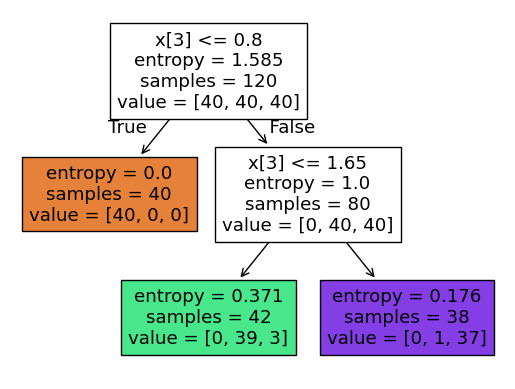

In [29]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plot_tree(decision_tree_classifier, filled=True)
plt.show()

********-Random Forest -- *************

In [42]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=30, max_depth=2, random_state=33)
rf_clf.fit(X_train, y_train)
predictions = rf_clf.predict(X_test)

# Calculate evaluation metrics and store them in variables
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average='weighted')
f1 = f1_score(y_test, predictions, average='weighted')

# Print the calculated metrics
print(f"Model's Accuracy: {accuracy:.4f}")
print(f"Model's Precision: {precision:.4f}")
print(f"Model's F1 Score: {f1:.4f}")

Model's Accuracy: 0.9667
,Model's Precision: 0.9697
,Model's F1 Score: 0.9666


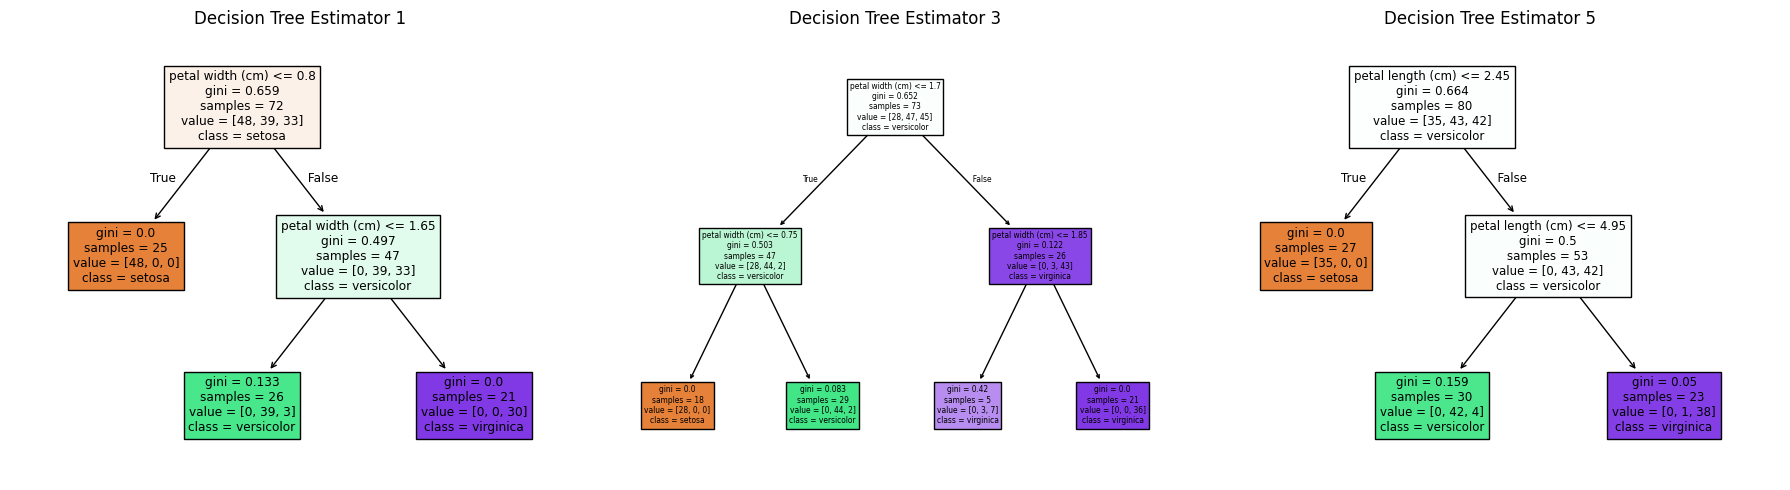

In [37]:
# Visualizing specific estimators (1st, 3rd, 5th)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

for i, idx in enumerate([0, 2, 4]):
    plot_tree(
        rf_clf.estimators_[idx],
        feature_names=iris.feature_names,
        class_names=iris.target_names,
        filled=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Decision Tree Estimator {idx + 1}")

plt.tight_layout()
plt.show()

**************** Decision Tree Implement from scratch ********************

** How the algorithm works
We'll start with all examples at the root node then:

We'll calculate information gain for splitting on all possible features and pick the one with the highest value

Then we'll split the data according to the selected feature

We'll repeat this process until stopping criteria is met

In [ ]:
class Node():
    """
    A class representing a node in a decision tree.
    """

    def __init__(self, feature=None, left=None, right=None, gain=None, value=None):
        """
        Initializes a new instance of the Node class.

        Args:
            feature: The feature used for splitting at this node. Defaults to None.
            threshold: The threshold used for splitting at this node. Defaults to None.
            left: The left child node. Defaults to None.
            right: The right child node. Defaults to None.
            gain: The gain of the split. Defaults to None.
            value: If this node is a leaf node, this attribute represents the predicted value
                for the target variable. Defaults to None.
        """
        self.feature = feature
        self.left = left
        self.right = right
        self.gain = gain
        self.value = value

In [ ]:
class DecisionTree():
    """
    A decision tree classifier for binary classification problems.
    """

    def __init__(self, min_samples=2, max_depth=2):
        """
        Constructor for DecisionTree class.

        Parameters:
            min_samples (int): Minimum number of samples required to split an internal node.
            max_depth (int): Maximum depth of the decision tree.
        """
        self.min_samples = min_samples
        self.max_depth = max_depth
        
        def split_data(self, dataset, feature):
            """
            Splits the given dataset into two datasets based on the given feature and threshold.
    
            Parameters:
                dataset (ndarray): Input dataset.
                feature (int): Index of the feature to be split on.
    
            Returns:
                left_dataset (ndarray): Subset of the dataset with values equal to the chosen category.
                right_dataset (ndarray): Subset of the dataset with values not equal to the chosen category.
            """
            # Create empty arrays to store the left and right datasets
            left_dataset = []
            right_dataset = []
        
            # Loop over each row in the dataset and split based on the given feature
            for row in dataset:
                if row[feature] == value:
                    left_dataset.append(row)
                else:
                    right_dataset.append(row)

            # Convert the left and right datasets to numpy arrays and return
            left_dataset = np.array(left_dataset)
            right_dataset = np.array(right_dataset)
            return left_dataset, right_dataset

        def entropy(self, y):
                    """
            Computes the entropy of the given label values.
    
            Parameters:
                y (ndarray): Input label values.
    
            Returns:
                entropy (float): Entropy of the given label values.
            """
            
            #TODO
            
            # Return the final entropy value
            return entropy
            
        def information_gain(self, parent, left, right):
            """
            Computes the information gain from splitting the parent dataset into two datasets.
    
            Parameters:
                parent (ndarray): Input parent dataset.
                left (ndarray): Subset of the parent dataset after split on a feature.
                right (ndarray): Subset of the parent dataset after split on a feature.
    
            Returns:
                information_gain (float): Information gain of the split.
            """
            #TODO

            return information_gain

        def best_split(self, dataset, num_samples, num_features):
            """
            Finds the best split for the given dataset.
    
            Args:
            dataset (ndarray): The dataset to split.
            num_samples (int): The number of samples in the dataset.
            num_features (int): The number of features in the dataset.
    
            Returns:
            dict: A dictionary with the best split feature index, threshold, gain, 
                  left and right datasets.
            """
            best_split_gain=-1
            for feature_index in range(num_features):
                #TODO get the feature values
                # get left and right datasets
                left_dataset, right_dataset = self.split_data(dataset, feature[feature_index])
                # check if either datasets is empty
                if len(left_dataset) and len(right_dataset):
                    #get y values of the parent and left, right nodes
                    y, left_y, right_y = dataset[:, -1], left_dataset[:, -1], right_dataset[:, -1]
                    # compute information gain based on the y values
                    information_gain = self.information_gain(y, left_y, right_y)
                    # update the best split if conditions are met
                    if information_gain > best_split_gain:
                        #TODO: update the best_split_gain and the corresponding feature and threshold
                        
        def build_tree(self, dataset, current_depth=0):
            """
            Recursively builds a decision tree from the given dataset.
    
            Args:
            dataset (ndarray): The dataset to build the tree from.
            current_depth (int): The current depth of the tree.
    
            Returns:
            Node: The root node of the built decision tree.
            """ 
            #TODO
            # return leaf node value
            return Node(value=leaf_value)
        
        def fit(self, X, y):
            """
            Builds and fits the decision tree to the given X and y values.
    
            Args:
            X (ndarray): The feature matrix.
            y (ndarray): The target values.
            """
            dataset = np.concatenate((X, y), axis=1)  
            self.root = self.build_tree(dataset)
        
        def predict(self, X):
            """
            Predicts the class labels for each instance in the feature matrix X.
    
            Args:
            X (ndarray): The feature matrix to make predictions for.
    
            Returns:
            list: A list of predicted class labels.
            """
            #TODO
            return predictions
        


        